# BioDYM Material Flow Analysis - Scientific Notebook

A streamlined notebook for Material Flow Analysis using the BioDYM framework with enhanced plotting capabilities. 

## Workflow Overview

This notebook follows a structured approach to Material Flow Analysis:

1. **Setup and Data Loading** - Prepare environment and load input data
2. **Calculation & Validation** - Execute MFA analysis and verify results
3. **Visualization** - Comprehensive analysis and exploration
4. **Scenario & Uncertainty Manager** - (Optional) Compare scenarios and run Monte Carlo analysis
5. **Data Export** - Save results and generate documentation

---

# 1. Setup and Data Loading

This section prepares the analysis environment and loads the input data.

## 1.1 Environment Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import display, HTML, Markdown
import copy

In [2]:
# Add BioDYM modules to path
src_path = os.path.join(os.getcwd(), 'src')
sys.path.insert(0, src_path)

In [3]:
# Add ODYM framework to path
project_root = os.getcwd()
odym_path = os.path.join(
    project_root, "framework", "ODYM-master_20241127", "odym", "modules"
)
sys.path.insert(0, odym_path)

In [4]:
# Add bioDYM add-on to path
biodym_addon_path = os.path.join(
    project_root, "framework", "bioDYM_add-on", "modules"
)
sys.path.insert(0, biodym_addon_path)

In [5]:
# Import BioDYM modules
try:
    import config
    import data_loader
    import system_setup
    import utils
    from engine import solver
    import plotting
    import ODYM_Classes as msc
    print("✅ BioDYM modules imported successfully")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("   Current Python path:")
    for i, path in enumerate(sys.path[:5]):  # Show first 5 paths
        print(f"   {i}: {path}")
    raise

✅ BioDYM modules imported successfully


In [6]:
# Set up plotting
plt.style.use('default')
print("📊 Plotting environment ready")

📊 Plotting environment ready


## 1.2 Data Input Configuration

In [7]:
# This is the only manual path setting required.
input_file = "data/01_input/251007_CS2_Wood_1_V2.xlsx"
print(f"📁 Input file: {input_file}")
if not os.path.exists(input_file):
    raise FileNotFoundError(f"Input file not found: {input_file}")

📁 Input file: data/01_input/251007_CS2_Wood_1_V2.xlsx


## 1.3 System Configuration Extraction

In [8]:
print("\n" + "="*60)
print("⚙️ EXTRACTING CONFIGURATION FROM EXCEL")
print("="*60)


⚙️ EXTRACTING CONFIGURATION FROM EXCEL


In [9]:
# Load the full dataset once. This will be passed to functions that need it.
input_data = pd.read_excel(
    input_file, sheet_name=None, header=0, engine='openpyxl', na_values=['N.A.', 'NA', 'n/a'], decimal=',')
print(f"✅ Excel file loaded: {len(input_data)} sheets")

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  

✅ Excel file loaded: 27 sheets


c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  

In [10]:
# Use the robust loader from the config module. This function handles all errors
# and fallbacks, guaranteeing a valid config object is returned.
config_obj = config.load_configuration(input_file)
print("✅ Configuration object loaded.")

✅ Found configuration sheet: '0_Configuration'
✅ Configuration object loaded.


In [11]:
# Extract core values from the config object, with fallbacks to data-driven values
try:
    start_year = int(config_obj.Start_Year)
    end_year = int(config_obj.End_Year)
    elements = [elem.strip() for elem in config_obj.Elements.split(',')]
except Exception as e:
    print(f"⚠️ Could not get time/elements from config object: {e}. Falling back to data-driven values.")
    flow_data = input_data['1_2_Data_Flows']
    years = sorted(flow_data['Year_Flow'].unique())
    start_year = int(min(years))
    end_year = int(max(years))
    elements = ['material', 'WC', 'DM', 'CC']

In [12]:
# Display final configuration summary
run_scenario = getattr(config_obj, 'Run_Scenario_Analysis', False)
selected_scenario = getattr(config_obj, 'Selected_Scenario_Name 1', getattr(config_obj, 'Selected_Scenario_Name', 'N/A'))

In [13]:
print(f"\n-- Configuration Summary --")
print(f"📅 Time range: {start_year} - {end_year}")
print(f"🧪 Elements: {elements}")
print(f"🎲 Monte Carlo: {'Enabled' if config_obj.RUN_MONTE_CARLO else 'Disabled'}")
print(f"📊 DSM Calculation: {'Enabled' if config_obj.RUN_DSM_CALCULATION else 'Disabled'}")
print(f"🌱 FOMP Calculation: {'Enabled' if config_obj.RUN_FOMP_CALCULATION else 'Disabled'}")
print(f"🎭 Scenario Analysis: {'Enabled' if run_scenario else 'Disabled'}")
if run_scenario:
    print(f"   -> Selected Scenario: '{selected_scenario}'")


-- Configuration Summary --
📅 Time range: 1950 - 2100
🧪 Elements: ['material', 'WC', 'DM', 'CC']
🎲 Monte Carlo: Disabled
📊 DSM Calculation: Enabled
🌱 FOMP Calculation: Disabled
🎭 Scenario Analysis: Enabled
   -> Selected Scenario: 'N/A'


# 2. Calculation and Validation

In [14]:
# ## 2.1 Model Initialization & Calculation
print("\n" + "="*60)
print("🚀 RUNNING BASELINE MFA CALCULATION")
print("="*60)


🚀 RUNNING BASELINE MFA CALCULATION


In [15]:
print("📋 Setting up model scope...")
model_classification, index_table = system_setup.define_model_scope(start_year, end_year, elements)

📋 Setting up model scope...
--> Model scope and classifications defined.


In [16]:
print("🔧 Initializing MFA system...")
mfa_system_base = system_setup.initialize_mfa_system(model_classification, index_table)

🔧 Initializing MFA system...
--> MFA system object initialized.


In [17]:
print("📊 Loading processes and data...")
mfa_system_base, all_excel_data = system_setup.load_and_define_processes(mfa_system_base, input_data, data_loader)

📊 Loading processes and data...
--> Defining process and stock structures...
--> Validating input data structure...
--> Input data validation successful.
--> Stock values initialized.


In [18]:
print("🔗 Defining flows and base parameters (e.g., compositions from flowsheet)...")
mfa_system_configured, _, flow_tc_map, process_logic_map = system_setup.define_flows_and_parameters(mfa_system_base, all_excel_data)

🔗 Defining flows and base parameters (e.g., compositions from flowsheet)...
--> Defining flows, parameters, and setting all initial values...
--> All flows initialized to zero.
--> Populated data for primary input flows.
--> Creating Flow-to-TC mapping...


In [19]:
print("⚙️ Loading all model parameters (TCs, DSM, FOMP)...")

⚙️ Loading all model parameters (TCs, DSM, FOMP)...


In [20]:
# Centralized call to the new, unified TC loader
time_vector = mfa_system_configured.IndexTable.Classification['Time'].Items
elements_list = mfa_system_configured.Elements
tc_params = data_loader.load_tc_parameters(all_excel_data, elements_list, time_vector)
mfa_system_configured.ParameterDict.update(tc_params) # Add the new TC params to the system

--> Loading Transfer Coefficients using unified TC_Type logic...
  -> Processing static TCs for 8 processes...
    -> Loaded static TC: TC_material_07_09 = 0.78
    -> Loaded static TC: TC_material_07_04 = 0.22
    -> Loaded static TC: TC_WC_10_00 = 0.0
    -> Loaded static TC: TC_DM_10_00 = 0.5
    -> Loaded static TC: TC_CC_10_00 = 1.0
    -> Loaded static TC: TC_WC_10_01 = 1.0
    -> Loaded static TC: TC_DM_10_01 = 0.5
    -> Loaded static TC: TC_CC_10_01 = 0.0
    -> Loaded static TC: TC_WC_04_00 = 0.0
    -> Loaded static TC: TC_DM_04_00 = 0.5
    -> Loaded static TC: TC_CC_04_00 = 1.0
    -> Loaded static TC: TC_WC_04_01 = 1.0
    -> Loaded static TC: TC_DM_04_01 = 0.5
    -> Loaded static TC: TC_CC_04_01 = 0.0
    -> Loaded static TC: TC_WC_08_00 = 0.0
    -> Loaded static TC: TC_DM_08_00 = 0.5
    -> Loaded static TC: TC_CC_08_00 = 1.0
    -> Loaded static TC: TC_WC_08_01 = 1.0
    -> Loaded static TC: TC_DM_08_01 = 0.5
    -> Loaded static TC: TC_CC_08_01 = 0.0
    -> Loaded s

In [21]:
# Load other special model parameters
dsm_params = data_loader.load_dsm_parameters(all_excel_data)
if config_obj.RUN_FOMP_CALCULATION:
    fomp_params = data_loader.load_fomp_parameters(all_excel_data)
else:
    fomp_params = {}
uncertainty_params = data_loader.load_uncertainty_definitions(all_excel_data)

--> Loading DSM parameters from sheet '3_1_Definition_DSM'...
--> Successfully loaded configurations for 2 DSM process(es).
--> Loading uncertainty definitions from sheet '4_1_Uncertainty_Parameters'...
  DEBUG: df_uncertainty before dropna:
    ID  Parameter  Parameter_Selection  Parameter_Name  Distribution  Mean  \
0    1        NaN                  NaN             NaN           NaN   NaN   
1    2        NaN                  NaN             NaN           NaN   NaN   
2    3        NaN                  NaN             NaN           NaN   NaN   
3    4        NaN                  NaN             NaN           NaN   NaN   
4    5        NaN                  NaN             NaN           NaN   NaN   
5    6        NaN                  NaN             NaN           NaN   NaN   
6    7        NaN                  NaN             NaN           NaN   NaN   
7    8        NaN                  NaN             NaN           NaN   NaN   
8    9        NaN                  NaN             NaN  

c:\Users\Johannes\Nextcloud\BioDYM\bioDYM-CERT-edit-main\src\data_loader.py:175: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dsm["Process_ID"] = df_dsm["Process_ID"].astype(int)


In [22]:
print("✅ All parameters loaded and configured.")

✅ All parameters loaded and configured.


In [23]:
print("🧮 Running baseline calculation...")
mfa_results_baseline, dsm_details_baseline = solver.run_mfa_calculation(mfa_system_configured, dsm_params, fomp_params, config_obj, flow_tc_map=flow_tc_map, process_logic_map=process_logic_map)
print("✅ Baseline calculation completed successfully!")

🧮 Running baseline calculation...
[DSM DEBUG] Iteration 0: Process 9, Inflows: ['F_07_09'], Total Inflow Sum: 0.00, Ready: False
[DSM DEBUG] Iteration 0: Process 5, Inflows: ['F_03_05'], Total Inflow Sum: 0.00, Ready: False
[DSM DEBUG] Iteration 1: Process 9, Inflows: ['F_07_09'], Total Inflow Sum: 9991229.83, Ready: True
inflow_category: [ 3025.54881613  2912.7924847   2643.50724635  2672.38513097
  2550.53454462  2898.56070081  2506.94841173  2807.94960514
  2887.24985073  2890.5851014   3067.60197667  3155.37500189
  3221.23066562  3143.98128845  3534.61993292  3463.27457091
  3746.25298123  3633.68309238  3507.60647413  3853.64390943
  4061.75526449  4099.18879212  4435.84195071  4687.9951872
  4842.65966828  4681.26253835  4548.45327124  4680.08173532
  4622.90600966  4492.33405356  4990.03217275  4899.71109888
  4905.8429883   5065.39640824  4943.71154863  5537.8626311
  5253.8277128   5298.69822794  5335.9038813   5732.0943716
  8235.43059456  6288.05543475  3363.47072922  3596.

## 2.2 Mass Balance Validation

In [24]:
print("\n" + "="*60)
print("⚖️ MASS BALANCE VERIFICATION (BASELINE)")
print("="*60)
plotting.plot_total_mass_balance_error(mfa_results_baseline)
plotting.plot_optimized_mass_balance_error(mfa_results_baseline)


⚖️ MASS BALANCE VERIFICATION (BASELINE)


interactive(children=(IntSlider(value=1950, description='Year', max=2100, min=1950), Dropdown(description='Ele…

FigureWidget({
    'data': [{'hovertemplate': '<b>%{x}</b><br>Error: %{y:.2e} Mg<extra></extra>',
              'marker': {'color': [#00C851, #00C851, #00C851, #00C851, #00C851,
                                   #00C851, #00C851, #00C851, #00C851, #00C851,
                                   #00C851, #00C851, #00C851],
                         'line': {'color': '#212529', 'width': 1}},
              'type': 'bar',
              'uid': 'f94f4019-8840-4d2c-ad80-f78143e6ebac',
              'x': [Atmosphere, Environment, Forestry, Roundwood Processing,
                    Incineration (CHP), Use-Phase (Wood), EoL-Sorting, Industrywood
                    Processing, Waste-Wood Incineration, Use-Phase (particle
                    board), Energy Wood Incineration, Industrywood -drying,
                    Roundwood -drying],
              'y': [0.0, 0.0, -5.820766091346741e-11, 0.0, 0.0, 0.0,
                    -5.684341886080802e-14, -7.275957614183426e-12,
                    5.68434188


--- System Flow Diagram (Graphviz) ---
🔍 Graphviz Analysis:
   Input: 46 processes, 69 flows
   Data Quality Check:
   - Complete processes: 13/46
   - Complete flows: 24/69
   - Connected processes: 13
   Final: 13 processes, 24 flows
   ✅ Graphviz chart created successfully!


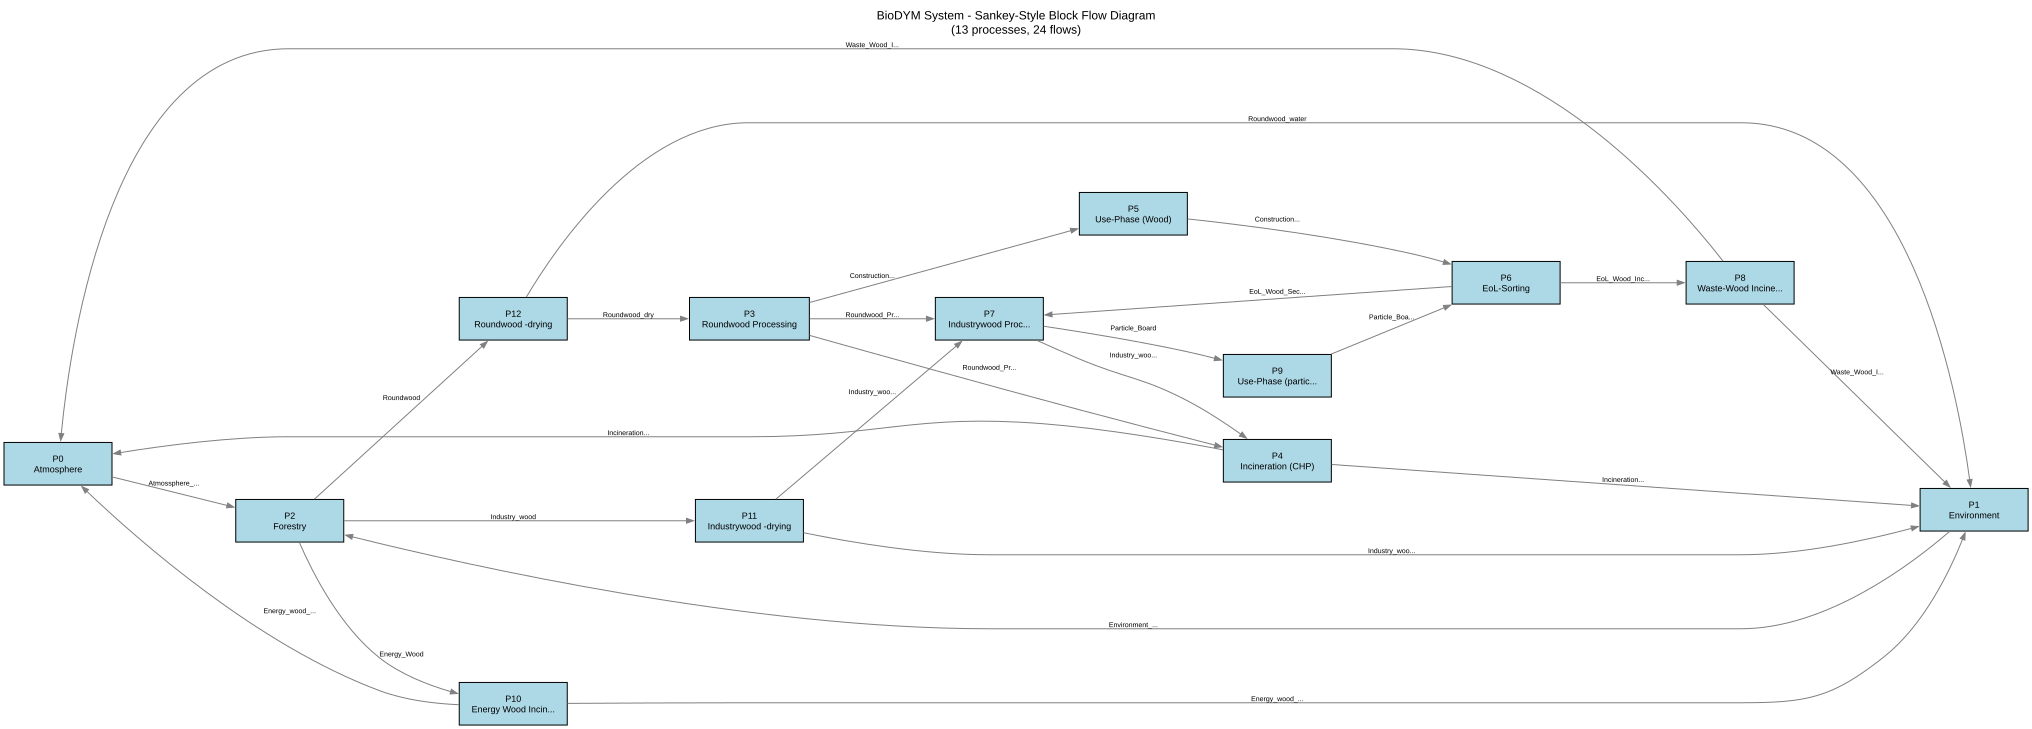

✅ Graphviz chart created successfully!


In [25]:
# ## 2.3 System Flow Diagram (Graphviz)
print("\n--- System Flow Diagram (Graphviz) ---")
try:
    from src.plotting.graphviz_flow_charts import plot_graphviz_flow_chart_sankey_style
    
    # Get the required dataframes from the loaded data
    processes_data = all_excel_data['2_1_Definition_Processes']
    flows_data = all_excel_data['1_1_Definition_Flows']
    
    # Generate and display the chart
    dot_chart = plot_graphviz_flow_chart_sankey_style(processes_data, flows_data)
    if dot_chart:
        display(dot_chart)
        print("✅ Graphviz chart created successfully!")
except ImportError:
    print("⚠️ Graphviz library not found. Skipping this plot.")
except Exception as e:
    print(f"⚠️ Graphviz chart failed: {e}")

# 3. Visualization

In [26]:
print("\n" + "="*60)
print("📊 VISUALIZATION (BASELINE)")
print("="*60)


📊 VISUALIZATION (BASELINE)


In [27]:
# ## 3.1 Traditional Sankey Diagram
print("\n--- Traditional Sankey Diagram ---")
plotting.plot_interactive_sankey(mfa_results_baseline, dsm_params, fomp_params)


--- Traditional Sankey Diagram ---


FigureWidget({
    'data': [{'arrangement': 'snap',
              'link': {'color': [#00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851],
                       'customdata': [Atmossphere_Input_C, Environment_Input_E,
                                      Roundwood, Energy_Wood, Industry_wood,
                                      Roundwood_Processing_Waste,
                                      Incineration(CHP)_Emissions_C,
                                      Incineration(CHP)_Emissions_E,
                                      Construction_Wood, Construction_Wood_EoL,
                                      EoL_Wood_Secondary_processing,
                                      EoL_Wood_Incinerat

In [28]:
# ## 3.2 Enhanced Sankey Diagram
print("\n--- Enhanced Sankey Diagram ---")
try:
    from src.plotting.enhanced_sankey import plot_enhanced_sankey
    print("🎯 Creating enhanced Sankey diagram...")
    plot_enhanced_sankey(
        mfa_system_results=mfa_results_baseline,
        dsm_params=dsm_params,
        fomp_params=fomp_params,
        visualization_config_path=input_file
    )
    print("✅ Enhanced Sankey diagram created successfully!")
except Exception as e:
    print(f"⚠️ Enhanced Sankey diagram failed: {e}")
    import traceback
    traceback.print_exc()


--- Enhanced Sankey Diagram ---
🎯 Creating enhanced Sankey diagram...
Loading visualization configuration from Excel...


c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed



  Loaded and processed 6_1_Visualization_Processes


c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed



  Loaded 6_2_Visualization_Flows
  Loaded 6_3_Layout_Configuration
Visualization configuration loaded successfully


✅ Enhanced Sankey diagram created successfully!


In [29]:
# ## 3.3 Additional Visualizations
print("\n--- Additional Visualizations ---")


--- Additional Visualizations ---


In [30]:
# ### 3.3.1 Core System Dynamics
print("\n📊 Core System Dynamics:")
print("   • Process Dynamics: Interactive 3-panel view (Inflow/Stock/Outflow)")
print("   • Flow Dynamics: Multi-flow time series analysis")
print("   • Stock Analysis: Interactive bar charts with time slider")


📊 Core System Dynamics:
   • Process Dynamics: Interactive 3-panel view (Inflow/Stock/Outflow)
   • Flow Dynamics: Multi-flow time series analysis
   • Stock Analysis: Interactive bar charts with time slider


In [31]:
# Process Dynamics - 3-panel view showing inflow, stock, and outflow for selected processes
print("\n🔄 Process Dynamics Analysis:")
plotting.plot_process_dynamics(mfa_results_baseline, all_excel_data['2_1_Definition_Processes'])


🔄 Process Dynamics Analysis:


interactive(children=(Dropdown(description='Process:', options=('Atmosphere', 'Environment', 'Forestry', 'Roun…

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Inflow',
              'type': 'scatter',
              'uid': '1f70388b-e8a3-4963-ade9-bf7d477881cb',
              'x': [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959,
                    1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969,
                    1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979,
                    1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
                    1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,
                    2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
                    2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
                    2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029,
                    2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039,
                    2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049,
                    2050, 20

In [32]:
# Flow Dynamics - Multi-flow time series with element selection
print("\n🌊 Flow Dynamics Analysis:")
plotting.plot_flow_dynamics(mfa_results_baseline)


🌊 Flow Dynamics Analysis:


interactive(children=(SelectMultiple(description='Flows:', index=(0,), options=('Atmossphere_Input_C', 'Enviro…

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Atmossphere_Input_C',
              'type': 'scatter',
              'uid': '31424d65-4e9d-4bf9-8cc2-f588268e4a46',
              'x': [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959,
                    1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969,
                    1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979,
                    1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
                    1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,
                    2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
                    2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
                    2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029,
                    2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039,
                    2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049,
               

In [33]:
# Stock Bar Chart - Interactive stock levels with time slider
print("\n📈 Stock Levels Analysis:")
plotting.plot_stock_bar_chart(mfa_results_baseline, title="Stock Levels Over Time (Baseline)")


📈 Stock Levels Analysis:


interactive(children=(IntSlider(value=1950, description='Year', max=2100, min=1950), Dropdown(description='Ele…

FigureWidget({
    'data': [{'hovertemplate': '<b>%{x}</b><br>Stock: %{y:.2f} Mg<extra></extra>',
              'marker': {'color': ['#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c']},
              'type': 'bar',
              'uid': '979b9f01-d064-45b4-ae88-801c4b3c4ede',
              'x': array(['Atmosphere', 'Environment', 'Use-Phase (Wood)',
                          'Use-Phase (particle board)'], dtype=object),
              'y': array([0., 0., 0., 0.])}],
    'layout': {'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10},
               'height': 800,
               'legend': {'bgcolor': 'rgba(255,255,255,0.8)',
                          'bordercolor': '#6C757D',
                          'borderwidth': 1,
                          'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10}},
               'margin': {'b': 100, 'l': 100, 'r': 50, 't': 100},
               'paper_bgcolor': '#FFFFFF',
               'plot_bgcolor': '#FFFFFF',
           

In [34]:
# System Stock Composition - Individual process stocks over time
print("\n🏗️ Individual Process Stocks Analysis:")
print("   • Individual process stocks over time")
print("   • Shows each process stock separately")
print("   • Element selection and bar/line chart options")
plotting.plot_system_stock_composition(mfa_results_baseline)


🏗️ Individual Process Stocks Analysis:
   • Individual process stocks over time
   • Shows each process stock separately
   • Element selection and bar/line chart options


FigureWidget({
    'data': [], 'layout': {'template': '...'}
})

In [35]:
# ### 3.3.2 Specialized Process Analysis (if applicable)
print("\n📊 Specialized Process Analysis:")


📊 Specialized Process Analysis:


In [36]:
# DSM Stock Details - Detailed DSM stock evolution (if DSM processes exist)
if dsm_params and dsm_details_baseline:
    print("\n🏗️ DSM Stock Evolution Analysis:")
    print("   • Individual and cumulative stock views")
    print("   • Lifetime analysis and category breakdown")
    plotting.plot_dsm_stock_details(mfa_results_baseline, dsm_params, dsm_details_baseline)
    
    print("\n🔄 DSM Process Dynamics Analysis:")
    print("   • Three-panel view: Input, Stock, Output")
    print("   • Stacked flows by element (Material, WC, DM, CC)")
    print("   • Dynamic material composition for DSM processes")
    plotting.plot_dsm_process_dynamics(mfa_results_baseline, dsm_params, dsm_details_baseline)
else:
    print("   ℹ️ No DSM processes found - skipping DSM analysis")


🏗️ DSM Stock Evolution Analysis:
   • Individual and cumulative stock views
   • Lifetime analysis and category breakdown


FigureWidget({
    'data': [], 'layout': {'template': '...'}
})

interactive(children=(Dropdown(description='DSM Process:', options=(5, 9), style=DescriptionStyle(description_…


🔄 DSM Process Dynamics Analysis:
   • Three-panel view: Input, Stock, Output
   • Stacked flows by element (Material, WC, DM, CC)
   • Dynamic material composition for DSM processes


FigureWidget({
    'data': [],
    'layout': {'annotations': [{'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Input Flows',
                                'x': 0.14444444444444446,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                                'yref': 'paper'},
                               {'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Stock Evolution',
                                'x': 0.5,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                                'yref': 'paper'},
                               {'font': {'size': 

In [37]:
# FOMP Analysis - FOMP mineralization analysis (if FOMP processes exist)
if fomp_params:
    print("\n🌱 FOMP Mineralization Analysis:")
    print("   • Organic matter accumulation and mineralization")
    print("   • Annual vs cumulative flow analysis")
    plotting.plot_fomp_stock_details(mfa_results_baseline, fomp_params)
    
    # FOMP Process Dynamics - Three-panel view of FOMP processes
    print("\n🔄 FOMP Process Dynamics:")
    print("   • Three panels: Input Flows (DM), Stock Evolution (DM), Mineralization Output (DM)")
    print("   • Decay rates displayed as percentages")
    print("   • Water Content (WC) excluded from mineralization")
    plotting.plot_fomp_dynamics(mfa_results_baseline, fomp_params)
else:
    print("   ℹ️ No FOMP processes found - skipping FOMP analysis")

   ℹ️ No FOMP processes found - skipping FOMP analysis


# 4. Scenario & Uncertainty Manager

In [38]:
# ## 4.1 Scenario Analysis & Comparison
print("\n" + "="*60)
print("🎭 SCENARIO ANALYSIS")
print("="*60)


🎭 SCENARIO ANALYSIS


In [39]:
# Import the new scenario engine
from engine import scenario_engine

In [40]:
# Run scenario analysis using the new engine
all_scenario_results, scenario_definitions = scenario_engine.run_scenario_analysis(
    config_obj=config_obj,
    mfa_system_configured=mfa_system_configured,
    all_excel_data=all_excel_data,
    dsm_params=dsm_params,
    fomp_params=fomp_params,
    flow_tc_map=flow_tc_map,
    process_logic_map=process_logic_map
)


🎭 SCENARIO ANALYSIS ENGINE
Found 4 scenarios to run: ['My baseline scenario', 'Reduced_Wood_Yield', 'Strong_reduced_wood_Yield', 'Increased_cascading_utilization']
--> Loading scenario definitions from sheet '5_1_Scenario_Manager'...
--> Successfully loaded 3 scenario(s).

🎭 RUNNING SCENARIO: 'My baseline scenario'
⚠️ WARNING: Scenario 'My baseline scenario' not found in '5_1_Scenario_Manager' sheet! Skipping.

🎭 RUNNING SCENARIO: 'Reduced_Wood_Yield'
    -> Applying: F_01_02 | Operation: multiply | Value: 0.85 (years 2025.0-2100.0)
    -> Applying: F_00_02 | Operation: multiply | Value: 0.85 (years 2025.0-2100.0)

    -> Recalculating elemental compositions for modified flows...

✅ Scenario modifications applied successfully.
[DSM DEBUG] Iteration 0: Process 9, Inflows: ['F_07_09'], Total Inflow Sum: 0.00, Ready: False
[DSM DEBUG] Iteration 0: Process 5, Inflows: ['F_03_05'], Total Inflow Sum: 0.00, Ready: False
[DSM DEBUG] Iteration 1: Process 9, Inflows: ['F_07_09'], Total Inflow S

In [41]:
# Generate visualizations if scenarios were run
if all_scenario_results:
    scenario_engine.generate_scenario_comparison_visualizations(
        baseline_results=mfa_results_baseline,
        all_scenario_results=all_scenario_results,
        scenario_definitions=scenario_definitions
    )
    
    # Export scenario results
    scenario_engine.export_scenario_results(
        all_scenario_results=all_scenario_results,
        scenario_definitions=scenario_definitions
    )
else:
    print("ℹ️ No scenarios were processed.")


📊 SCENARIO COMPARISON VISUALIZATIONS
📈 Generating multi-scenario comparison plot...


📈 Generating scenario flow dynamics plot...


✅ Scenario comparison visualizations completed!

📁 Exporting scenario results to data/02_output...
--> Exporting results to 'data/02_output/scenario_Reduced_Wood_Yield_20251007_114126.xlsx'...
✅ Results successfully exported to data/02_output/scenario_Reduced_Wood_Yield_20251007_114126.xlsx
--> Exporting results to 'data/02_output/scenario_Strong_reduced_wood_Yield_20251007_114126.xlsx'...
✅ Results successfully exported to data/02_output/scenario_Strong_reduced_wood_Yield_20251007_114126.xlsx
--> Exporting results to 'data/02_output/scenario_Increased_cascading_utilization_20251007_114126.xlsx'...
✅ Results successfully exported to data/02_output/scenario_Increased_cascading_utilization_20251007_114126.xlsx
✅ Scenario results exported successfully!


In [42]:
# ## 4.2 Monte Carlo Analysis
print("\n" + "="*60)
print("🎲 MONTE CARLO SIMULATION (BASELINE)")
print("="*60)


🎲 MONTE CARLO SIMULATION (BASELINE)


In [43]:
if config_obj.RUN_MONTE_CARLO and '4_1_Uncertainty_Parameters' in input_data:
    try:
        from engine.mc_simulation import run_mc_simulation
        from src.plotting.monte_carlo import (
            plot_interactive_mc_multiple_histograms,
            plot_interactive_tornado, 
            plot_interactive_mc_paths, 
            plot_interactive_mc_stock_comparison
        )
        
        mc_results = run_mc_simulation(
            mfa_system_configured, 
            input_data, 
            dsm_params, 
            fomp_params, 
            config_obj, 
            process_logic_map=process_logic_map, 
            flow_tc_map=flow_tc_map
        )
        
        if mc_results is not None and not mc_results.empty:
            print("✅ Monte Carlo simulation completed for baseline.")
            print("\n📊 Monte Carlo Analysis Visualizations:")
            print("   • Multiple Distribution Histograms: Interactively select and view histograms for multiple stocks.")
            print("   • Sensitivity Tornado Plot: Identify which parameters most influence outcomes.")
            print("   • Simulation Paths: Visualize the trajectories of all Monte Carlo runs.")
            print("   • Stock Comparison: Compare distributions of several stocks in one plot.")

            # This new function allows selecting multiple histograms, making the old single one redundant.
            plot_interactive_mc_multiple_histograms(mc_results, mfa_results_baseline)
            
            plot_interactive_tornado(mc_results)
            plot_interactive_mc_paths(mc_results, mfa_results_baseline)
            plot_interactive_mc_stock_comparison(mc_results, mfa_results_baseline)
            
    except Exception as e:
        print(f"⚠️ Monte Carlo simulation failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("ℹ️ Monte Carlo analysis is disabled or no uncertainty parameters are defined. Skipping.")

ℹ️ Monte Carlo analysis is disabled or no uncertainty parameters are defined. Skipping.


# 5. Data Export

In [44]:
print("\n" + "="*60)
print("💾 EXPORTING BASELINE RESULTS")
print("="*60)


💾 EXPORTING BASELINE RESULTS


In [45]:
output_file = "data/02_output/results_scientific_baseline.xlsx"
utils.export_results_to_excel(mfa_results_baseline, output_file, input_file_path=input_file)
print(f"✅ Baseline results exported to: {output_file}")

--> Exporting results to 'data/02_output/results_scientific_baseline.xlsx'...
✅ Results successfully exported to data/02_output/results_scientific_baseline.xlsx
✅ Baseline results exported to: data/02_output/results_scientific_baseline.xlsx


In [46]:
print("\n" + "="*60)
print("🎉 ANALYSIS COMPLETE")
print("="*60)


🎉 ANALYSIS COMPLETE
